# 03. Feature Engineering & Dataset Preparation

**Project Objective**: Predict residential real estate sale prices in **Capital Federal (CABA)**, Argentina.
**Input**: `../data/interim/properties_cleaned.parquet` (Cleaned listings with metadata & raw description)
**Output**: `../data/processed/properties_features.parquet` (Lightweight, dense, model-ready feature table)

### Feature Engineering Strategy:
1. **Regex Amenity Extraction**: Mine unstructured `title` and `description` for high-value building features (`has_parking`, `has_pool`, `has_gym`, `has_security`, `has_parrilla`, `has_sum`, `is_a_estrenar`, `has_balcony`) with negation handling.
2. **Surface & Space Ratios**: Decompose collinear surfaces into `uncovered_surface`, `covered_ratio`, and `uncovered_ratio`.
3. **Room & Density Metrics**: Engineer `is_monoambiente`, `avg_room_size`, `bathrooms_per_bedroom`, and `rooms_per_bedroom`.
4. **Geospatial Distance Features**: Calculate Haversine distances to key economic hubs (`Obelisco`, `Puerto Madero`, `Palermo Soho`).
5. **Categorical Encodings**: One-Hot encode property types and frequency-encode neighborhoods (`barrio`).
6. **Target Formulations**: Prepare $y = \log(1 + Price)$ as primary modeling target alongside nominal and 30% inflation-adjusted USD prices.
7. **Dataset Optimization & Export**: Drop verbose text strings and save compressed Parquet table (~3 MB).


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Environment and libraries initialized.')


Environment and libraries initialized.


## 1. Data Ingestion
Load the interim dataset from `../data/interim/properties_cleaned.parquet`.


In [2]:
interim_path = Path('../data/interim/properties_cleaned.parquet')
df = pd.read_parquet(interim_path)

print(f'Interim dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB')
df.head(2)


Interim dataset loaded: 57,505 rows, 21 columns
Memory usage: 72.19 MB


## 2. Regex Amenity Extraction Pipeline
Real estate listings in Buenos Aires contain decisive pricing signals inside free-form text. We extract 8 specific building features using regular expressions with **negation handling** (e.g. *"sin cochera"* or *"no tiene pileta"* are mapped to 0).


In [3]:
# Combine title and description into lowercase search corpus
text_corpus = (df['title'].fillna('') + ' ' + df['description'].fillna('')).str.lower()

def extract_amenity(corpus, positive_regex, negative_regex=None):
    has_positive = corpus.str.contains(positive_regex, regex=True, na=False)
    if negative_regex:
        has_negative = corpus.str.contains(negative_regex, regex=True, na=False)
        return (has_positive & ~has_negative).astype(np.int8)
    return has_positive.astype(np.int8)

# Define regex patterns with non-capturing groups
amenity_definitions = {
    'has_parking': (
        r'\b(?:cochera|cocheras|garage|estacionamiento|guardacoche|guarda coche)\b',
        r'\b(?:sin cochera|sin garage|no tiene cochera|no tiene garage|cochera opcional|cochera disponible para alquilar)\b'
    ),
    'has_pool': (
        r'\b(?:pileta|piscina|swimming)\b',
        r'\b(?:sin pileta|sin piscina|no tiene pileta|no tiene piscina)\b'
    ),
    'has_gym': (
        r'\b(?:gimnasio|gym|fitness)\b',
        r'\b(?:sin gimnasio|no tiene gimnasio)\b'
    ),
    'has_security': (
        r'\b(?:seguridad|vigilancia|vigilador|portero 24|porteria 24|24 hs|24hs|ojo de halc[oó]n|totem|cctv)\b',
        None
    ),
    'has_parrilla': (
        r'\b(?:parrilla|parrillero|asador|quincho)\b',
        r'\b(?:sin parrilla|no tiene parrilla)\b'
    ),
    'has_sum': (
        r'\b(?:sum|s\.u\.m\.|sal[oó]n de usos m[uú]ltiples|sal[oó]n de fiestas)\b',
        None
    ),
    'is_a_estrenar': (
        r'\b(?:a estrenar|en pozo|emprendimiento|obra nueva)\b',
        None
    ),
    'has_balcony': (
        r'\b(?:balc[oó]n|terraza|patio|jard[ií]n)\b',
        r'\b(?:sin balc[oó]n|sin terraza|no tiene balc[oó]n)\b'
    )
}

# Apply extraction
for col_name, (pos_pat, neg_pat) in amenity_definitions.items():
    df[col_name] = extract_amenity(text_corpus, pos_pat, neg_pat)

# Composite feature: total amenities count
amenity_cols = list(amenity_definitions.keys())
df['amenities_count'] = df[amenity_cols].sum(axis=1).astype(np.int8)

# Summary report
amenity_summary = pd.DataFrame({
    'Amenity': amenity_cols + ['amenities_count (mean)'],
    'Matched Listings': [df[col].sum() for col in amenity_cols] + [df['amenities_count'].sum()],
    'Prevalence %': [(df[col].mean() * 100) for col in amenity_cols] + [df['amenities_count'].mean()]
})
print('=== EXTRACTED AMENITIES SUMMARY ===')
print(amenity_summary.to_string(index=False))


=== EXTRACTED AMENITIES SUMMARY ===
               Amenity  Matched Listings  Prevalence %
           has_parking             19329         33.61
              has_pool             10833         18.84
               has_gym              5496          9.56
          has_security             10284         17.88
          has_parrilla             12698         22.08
               has_sum              9596         16.69
         is_a_estrenar              8003         13.92
           has_balcony             42014         73.06
amenities_count (mean)            118253          2.06


### Visualizing Price Premiums of Extracted Amenities
We inspect the median price differential associated with parking, pool, gym, and security.


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


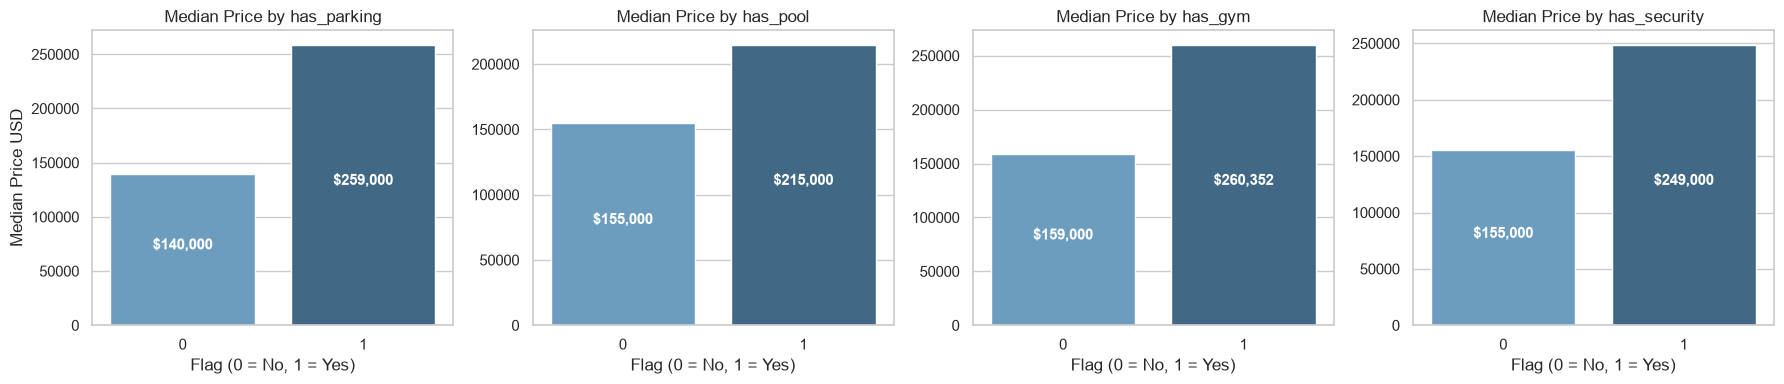

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
top_amenities = ['has_parking', 'has_pool', 'has_gym', 'has_security']

for i, am in enumerate(top_amenities):
    sns.barplot(data=df, x=am, y='price_usd', ax=axes[i], estimator=np.median, errorbar=None, palette='Blues_d')
    axes[i].set_title(f'Median Price by {am}')
    axes[i].set_xlabel('Flag (0 = No, 1 = Yes)')
    axes[i].set_ylabel('Median Price USD' if i == 0 else '')
    for p in axes[i].patches:
        axes[i].annotate(f'${p.get_height():,.0f}',
                         (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                         ha='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## 3. Surface & Room Metrics Engineering
To solve multicollinearity between `surface_total` and `surface_covered` ($r = 0.944$), we decompose them into:
- **`uncovered_surface`**: Total minus covered area (balcony, patio, garden, terrace).
- **`covered_ratio`** & **`uncovered_ratio`**: Proportions of built vs open-air surface.
- **`is_monoambiente`**: Single-room studio apartment indicator.
- **`avg_room_size`**: Built area divided by room count.
- **`bathrooms_per_bedroom`** & **`rooms_per_bedroom`**: Space layout density.


In [5]:
# Surface deltas and proportions
df['uncovered_surface'] = np.maximum(0.0, df['surface_total'] - df['surface_covered'])
df['covered_ratio'] = (df['surface_covered'] / df['surface_total']).clip(0.0, 1.0).round(3)
df['uncovered_ratio'] = (df['uncovered_surface'] / df['surface_total']).clip(0.0, 1.0).round(3)

# Room layout metrics
df['is_monoambiente'] = (df['rooms'] == 1).astype(np.int8)
df['avg_room_size'] = (df['surface_covered'] / df['rooms']).round(2)
bedrooms_safe = df['bedrooms'].fillna(0)
df['bathrooms_per_bedroom'] = (df['bathrooms'] / (bedrooms_safe + 1)).round(2)
df['rooms_per_bedroom'] = (df['rooms'] / (bedrooms_safe + 1)).round(2)

engineered_num_cols = [
    'uncovered_surface', 'covered_ratio', 'uncovered_ratio',
    'is_monoambiente', 'avg_room_size', 'bathrooms_per_bedroom', 'rooms_per_bedroom'
]
print('=== SURFACE & ROOM ENGINEERED FEATURES DESCRIBE ===')
print(df[engineered_num_cols].describe().round(2))


=== SURFACE & ROOM ENGINEERED FEATURES DESCRIBE ===
       uncovered_surface  covered_ratio  uncovered_ratio  is_monoambiente  \
count          57,505.00      57,505.00        57,505.00        57,505.00   
mean               12.44           0.89             0.11             0.18   
std                26.14           0.13             0.13             0.39   
min                 0.00           0.06             0.00             0.00   
25%                 0.00           0.86             0.00             0.00   
50%                 4.00           0.92             0.08             0.00   
75%                11.00           1.00             0.14             0.00   
max               442.00           1.00             0.94             1.00   

       avg_room_size  bathrooms_per_bedroom  rooms_per_bedroom  
count      57,505.00              57,505.00          57,505.00  
mean           28.04                   0.84               1.49  
std            12.27                   0.64               1

## 4. Geospatial Distance Features (Haversine Formula)
In CABA, location valuation follows distinct geographic poles. We compute direct spherical distance (in kilometers) to:
1. **Obelisco / Microcentro** (`lat: -34.6037, lon: -58.3816`): Historic financial & business district.
2. **Puerto Madero Waterfront** (`lat: -34.6118, lon: -58.3619`): Highest valuation hub in Argentina.
3. **Palermo Soho** (`lat: -34.5885, lon: -58.4306`): Cultural, dining, and trendy residential epicenter.


In [6]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Compute Haversine spherical distance in km between coordinate pairs."""
    r = 6371.0  # Earth radius in km
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2.0)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return r * c

POLES = {
    'dist_obelisco_km': (-34.6037, -58.3816),
    'dist_puerto_madero_km': (-34.6118, -58.3619),
    'dist_palermo_soho_km': (-34.5885, -58.4306)
}

for col_name, (pole_lat, pole_lon) in POLES.items():
    df[col_name] = haversine_distance_km(df['lat'], df['lon'], pole_lat, pole_lon).round(2)

print('=== GEOSPATIAL DISTANCES SUMMARY (KM) ===')
print(df[list(POLES.keys())].describe().round(2))


=== GEOSPATIAL DISTANCES SUMMARY (KM) ===
       dist_obelisco_km  dist_puerto_madero_km  dist_palermo_soho_km
count         57,505.00              57,505.00             57,505.00
mean               6.09                   7.72                  4.16
std                3.34                   3.57                  2.21
min                0.00                   0.02                  0.01
25%                3.28                   4.95                  2.38
50%                5.75                   7.55                  3.98
75%                8.80                  10.71                  5.59
max               14.48                  15.88                 12.42


## 5. Categorical Feature Encodings
- **`property_type`**: One-Hot Encoded into `is_departamento`, `is_casa`, `is_ph`.
- **`barrio`**: Frequency encoded (`barrio_listing_freq`), representing market liquidity and supply density.
- **Missing values**: Map any rare null barrio entries to `'Desconocido'`.


In [7]:
# 1. One-hot encoding for property_type
pt_dummies = pd.get_dummies(df['property_type'], prefix='is', dtype=np.int8)
df = pd.concat([df, pt_dummies], axis=1)

# 2. Barrio handling & frequency encoding
df['barrio'] = df['barrio'].astype(str).replace('nan', 'Desconocido')
barrio_counts = df['barrio'].value_counts()
df['barrio_listing_freq'] = df['barrio'].map(barrio_counts).fillna(0).astype(int)

print('One-hot property type columns created:', list(pt_dummies.columns))
print(f'Barrio unique categories encoded: {df["barrio"].nunique()}')


One-hot property type columns created: ['is_Casa', 'is_Departamento', 'is_PH']
Barrio unique categories encoded: 57


## 6. Target Variable Formulations
We establish three target variables:
1. **`target_log_price`**: $\mathbf{\log(1 + Price_{USD})}$ (Primary target for model optimization, stabilizing variance).
2. **`target_price_usd`**: Nominal 2019 / 2026 market price in USD.
3. **`target_price_usd_infl_adj`**: 30% cumulative USD inflation-adjusted price (constant 2026 purchasing power).


In [8]:
df['target_log_price'] = np.log1p(df['price_usd']) 
df['target_price_usd'] = df['price_usd']
df['target_price_usd_infl_adj'] = df['price_usd_infl_adj']

print('=== TARGET VARIABLES CHECK ===')
print(df[['target_price_usd', 'target_price_usd_infl_adj', 'target_log_price']].describe().round(2))


=== TARGET VARIABLES CHECK ===
       target_price_usd  target_price_usd_infl_adj  target_log_price
count         57,505.00                  57,505.00         57,505.00
mean         237,655.80                 308,952.54             12.11
std          239,428.76                 311,257.38              0.66
min           22,000.00                  28,600.00             10.00
25%          115,000.00                 149,500.00             11.65
50%          165,000.00                 214,500.00             12.01
75%          265,000.00                 344,500.00             12.49
max        3,000,000.00               3,900,000.00             14.91


## 7. Feature Correlation Ranking with Target
We inspect linear correlation between all numerical features and the primary target `target_log_price`.


=== FEATURE CORRELATIONS WITH TARGET LOG PRICE ===
target_log_price         1.00
surface_covered          0.77
surface_total            0.74
bathrooms                0.71
rooms                    0.67
bedrooms                 0.65
has_parking              0.44
avg_room_size            0.42
amenities_count          0.35
rooms_per_bedroom        0.33
uncovered_surface        0.32
bathrooms_per_bedroom    0.32
lat                      0.29
has_security             0.28
barrio_listing_freq      0.27
has_gym                  0.23
has_pool                 0.21
is_Casa                  0.18
has_balcony              0.17
has_parrilla             0.14
uncovered_ratio          0.13
has_sum                  0.11
lon                      0.07
is_PH                   -0.02
dist_puerto_madero_km   -0.02
dist_obelisco_km        -0.03
is_a_estrenar           -0.07
is_Departamento         -0.10
dist_palermo_soho_km    -0.11
covered_ratio           -0.13
is_monoambiente         -0.41
Name: target_log_pr

<string>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


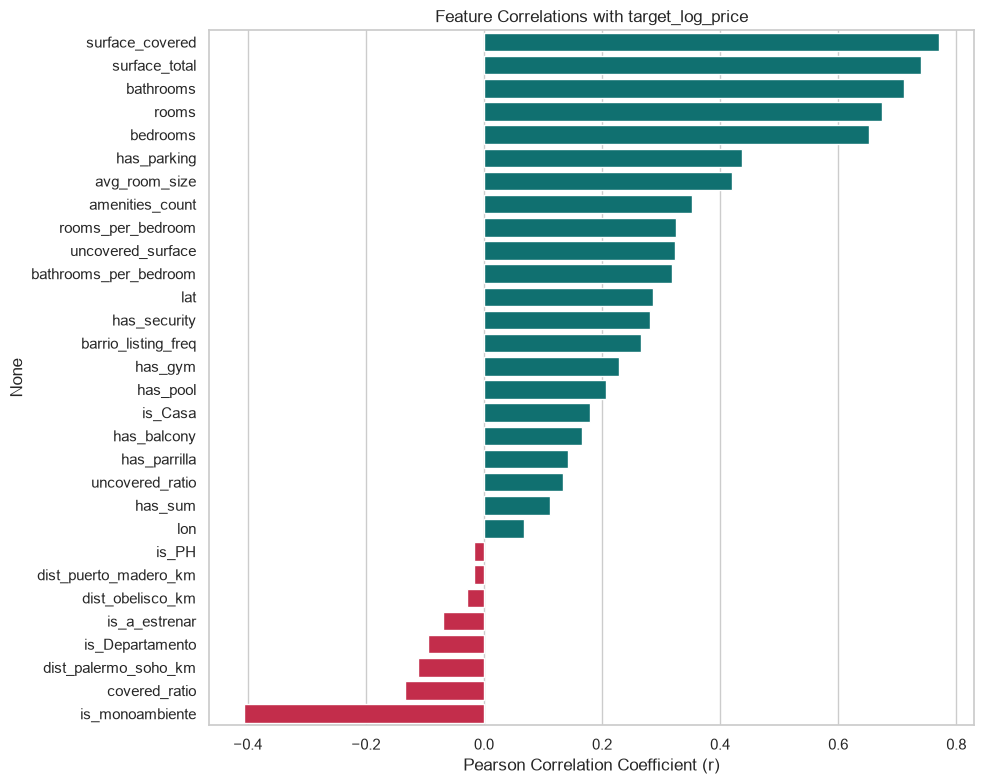

In [9]:
# Exclude target aliases from correlation table
exclude_cols = ['price', 'price_usd', 'price_usd_infl_adj', 'price_usd_per_m2', 'price_usd_infl_adj_per_m2',
                'target_price_usd', 'target_price_usd_infl_adj']

numeric_df = df.select_dtypes(include=[np.number]).drop(columns=exclude_cols, errors='ignore')
correlations = numeric_df.corr()['target_log_price'].sort_values(ascending=False)

print('=== FEATURE CORRELATIONS WITH TARGET LOG PRICE ===')
print(correlations.round(3))

# Visual Barplot
plt.figure(figsize=(10, 8))
corr_plot_data = correlations.drop('target_log_price')
colors = ['crimson' if x < 0 else 'teal' for x in corr_plot_data.values]
sns.barplot(x=corr_plot_data.values, y=corr_plot_data.index, palette=colors)
plt.title('Feature Correlations with target_log_price')
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.tight_layout()
plt.show()


## 8. Export Processed Modeling Table
We drop the verbose unstructured string columns (`title`, `description`) to optimize disk space and training speed. The final clean feature table is saved to `../data/processed/properties_features.parquet` (~2.6 MB).


In [10]:
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Drop raw free text columns
text_cols_to_drop = [col for col in ['title', 'description', 'sub_barrio'] if col in df.columns]
df_modeling = df.drop(columns=text_cols_to_drop)

output_path = output_dir / 'properties_features.parquet'
df_modeling.to_parquet(output_path, compression='zstd', index=False)

print(f'Successfully exported final modeling dataset!')
print(f'File location: {output_path}')
print(f'File size: {output_path.stat().st_size / (1024**2):.2f} MB')
print(f'Dimensions: {df_modeling.shape[0]:,} rows, {df_modeling.shape[1]} columns')
print(f'Missing values: {df_modeling.isna().sum().sum()}')


Successfully exported final modeling dataset!
File location: ..\data\processed\properties_features.parquet
File size: 3.50 MB
Dimensions: 57,505 rows, 44 columns
Missing values: 26662
